# Kaggle Housing Price Predictions

In [256]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import joblib


rawDf = pd.read_csv("DataSet/train.csv")
pd.set_option('display.max_columns', None)
rawDf.set_index("Id", inplace = True)
rawDf

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


In [216]:
rawDf.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [217]:
rawDf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

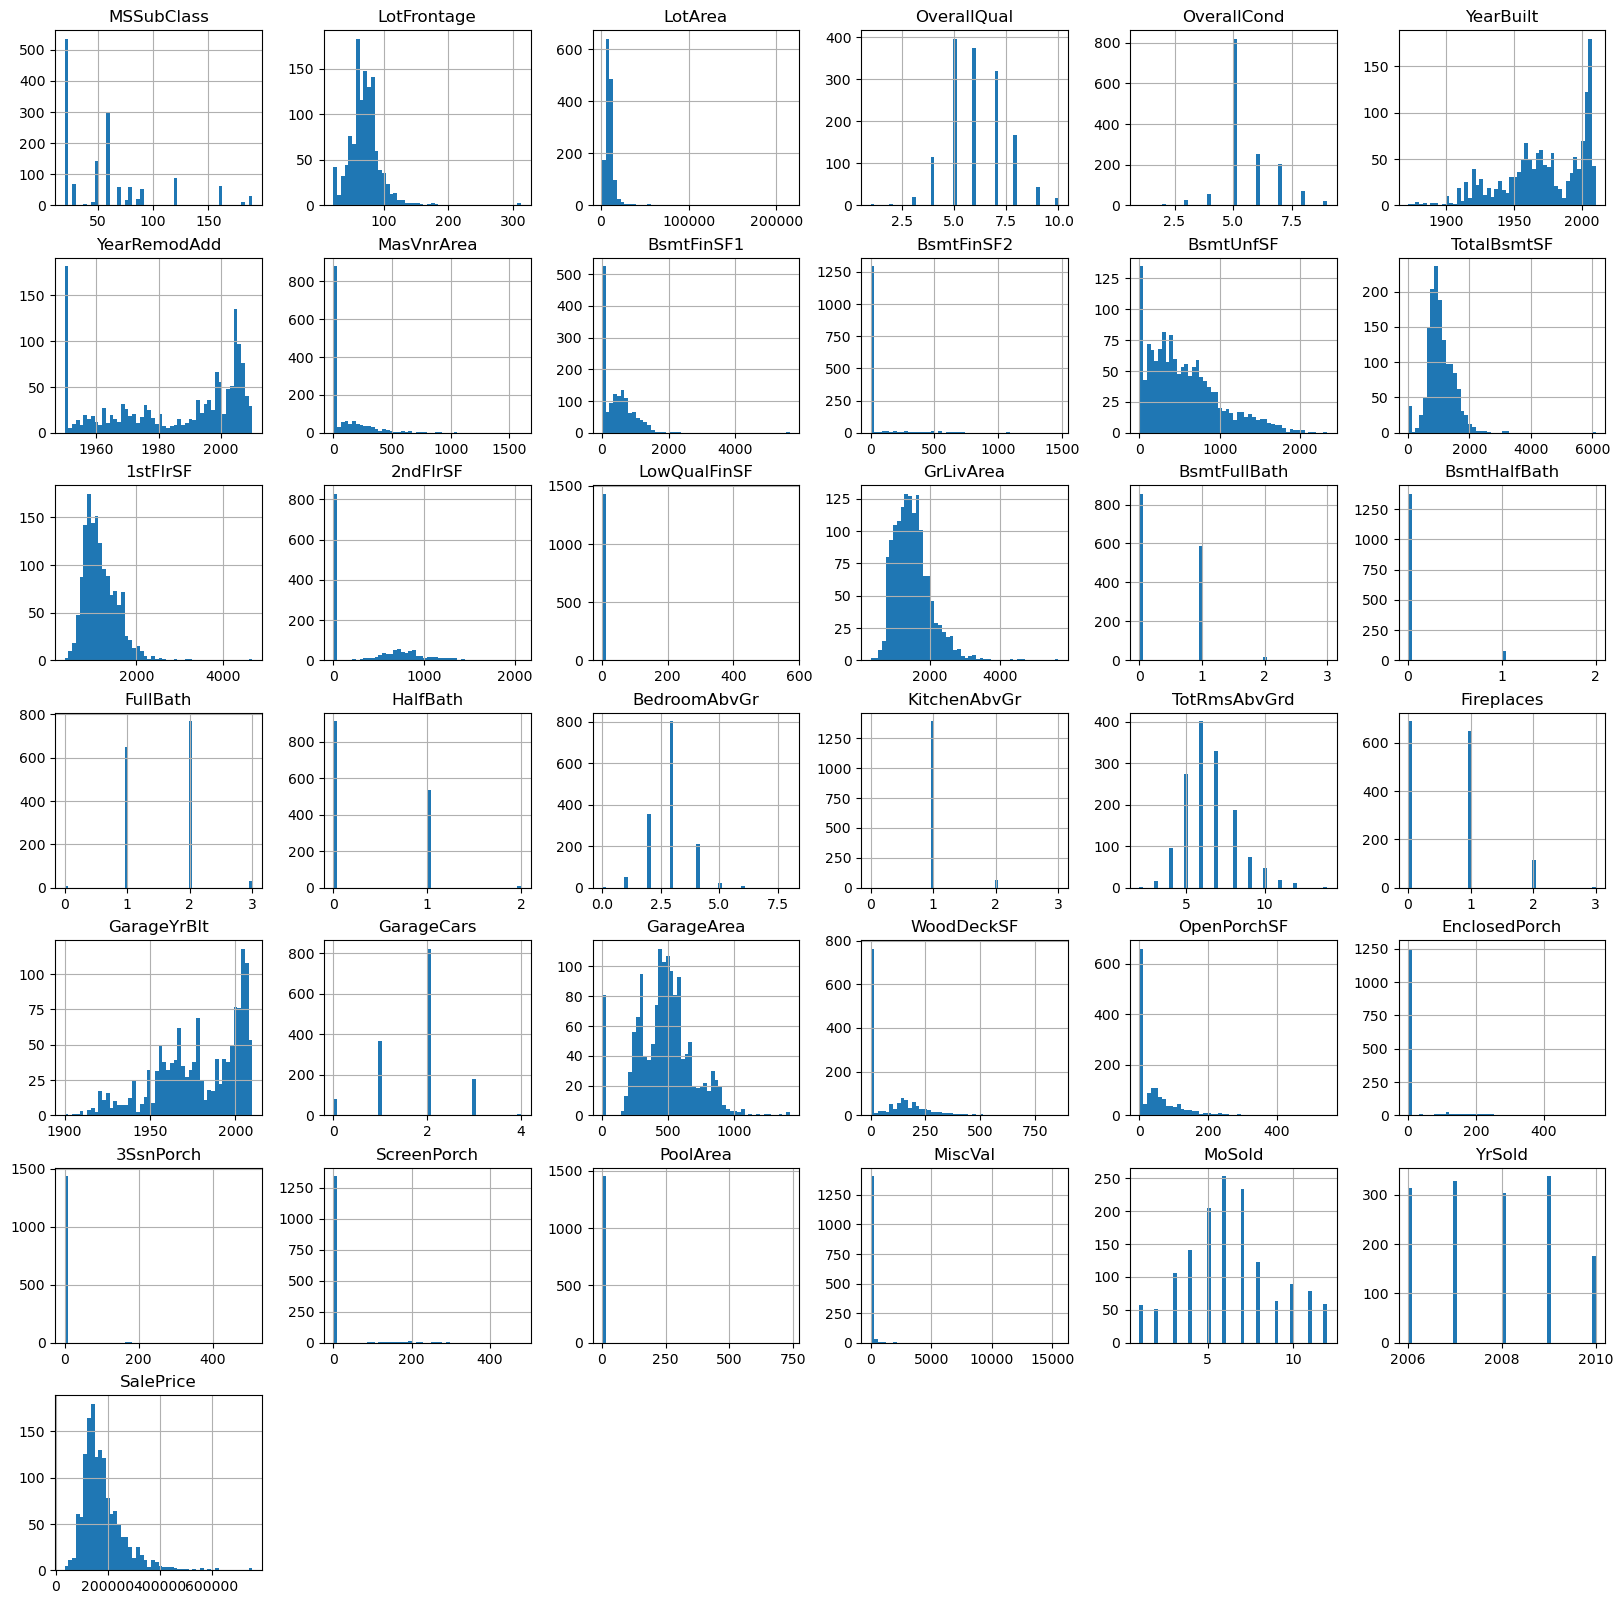

In [218]:
rawDf.hist(figsize=(20,20), bins=50)

In [219]:
rawDf.select_dtypes(include=np.number).corr()["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

In [220]:
processedDF = rawDf.copy()

In [221]:
processedDF["Alley"]

Id
1       NaN
2       NaN
3       NaN
4       NaN
5       NaN
       ... 
1456    NaN
1457    NaN
1458    NaN
1459    NaN
1460    NaN
Name: Alley, Length: 1460, dtype: object

In [222]:
processedDF["Alley"].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

In [223]:
processedDF["Utilities"].value_counts()

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

In [224]:
processedDF["LandSlope"].value_counts()

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

In [225]:
processedDF["LotShape"].value_counts()

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

In [226]:
processedDF["OverallQual"].value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

In [227]:
processedDF["MasVnrArea"].isnull().value_counts()

MasVnrArea
False    1452
True        8
Name: count, dtype: int64

In [228]:
processedDF["BsmtQual"].isnull().value_counts()

BsmtQual
False    1423
True       37
Name: count, dtype: int64

In [229]:
processedDF["BsmtFinType1"].value_counts()

BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
Name: count, dtype: int64

In [230]:
processedDF["BsmtFinType1"].isnull().value_counts()

BsmtFinType1
False    1423
True       37
Name: count, dtype: int64

In [231]:
processedDF["BsmtFinSF1"].isnull().value_counts()

BsmtFinSF1
False    1460
Name: count, dtype: int64

In [232]:
processedDF["BsmtFinSF1"].value_counts()

BsmtFinSF1
0       467
24       12
16        9
686       5
936       5
       ... 
203       1
309       1
408       1
1282      1
548       1
Name: count, Length: 637, dtype: int64

In [233]:
print(processedDF["BsmtFinType2"].value_counts())
processedDF["BsmtFinType2"].isnull().value_counts()

BsmtFinType2
Unf    1256
Rec      54
LwQ      46
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64


BsmtFinType2
False    1422
True       38
Name: count, dtype: int64

In [234]:
processedDF["FireplaceQu"].isnull().value_counts()

FireplaceQu
False    770
True     690
Name: count, dtype: int64

In [235]:
processedDF["FireplaceQu"].value_counts()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

In [236]:
processedDF["MiscVal"].isnull().value_counts()

MiscVal
False    1460
Name: count, dtype: int64

In [237]:
class BsmtFin1Interaction(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = OrdinalEncoder(
            categories=[["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

    def fit(self, X, y=None):
        X = X.copy()

        type_col = X["BsmtFinType1"].fillna("NA").to_frame()

        self.encoder.fit(type_col)
        return self

    def transform(self, X):
        X = X.copy()

        type_col = X["BsmtFinType1"].fillna("NA").to_frame()
        sf = X["BsmtFinSF1"].fillna(0).to_numpy()

        enc = self.encoder.transform(type_col).ravel()

        return (enc * sf).reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(["BsmtFin1core"])




class BsmtFin2Interaction(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = OrdinalEncoder(
            categories=[["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

    def fit(self, X, y=None):
        X = X.copy()

        type_col = X["BsmtFinType2"].fillna("NA").to_frame()

        self.encoder.fit(type_col)
        return self

    def transform(self, X):
        X = X.copy()

        type_col = X["BsmtFinType2"].fillna("NA").to_frame()
        sf = X["BsmtFinSF2"].fillna(0).to_numpy()

        enc = self.encoder.transform(type_col).ravel()

        return (enc * sf).reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(["BsmtFin2CScore"])

In [238]:

class PoolQCInteraction(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = OrdinalEncoder(
            categories=[["NA", "Fa", "TA", "Gd", "Ex"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

    def fit(self, X, y=None):
        X = X.copy()

        qc = X["PoolQC"].fillna("NA").to_frame()

        self.encoder.fit(qc)
        return self

    def transform(self, X):
        X = X.copy()

        qc = X["PoolQC"].fillna("NA").to_frame()
        area = X["PoolArea"].fillna(0).to_numpy()

        enc = self.encoder.transform(qc).ravel()

        return (enc * area).reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(["PoolQCScore"])

In [239]:
def toString(x):
    return x.astype(str)


CatMSSubClassPipeline = Pipeline(
    [
        ("Impute", SimpleImputer(strategy="most_frequent")),
        ("ChangeToString", FunctionTransformer(toString, feature_names_out="one-to-one")),
        ("Encode", OneHotEncoder(handle_unknown="ignore"))
    ]
)

flagImputePipeline = Pipeline([
    ("Impute", SimpleImputer(strategy="constant", fill_value="NoAlleyAccess")),
    ("Encode", OneHotEncoder(handle_unknown="ignore"))
])


UtilitiesPipeline = Pipeline([
    ("Impute", SimpleImputer(strategy="most_frequent")),
    ("Encode", OrdinalEncoder(categories=[["ELO", "NoSeWa", "NoSewr", "AllPub"]]))
])

landSlopePipeline = Pipeline([
    ("Impute", SimpleImputer(strategy="most_frequent")),
    ("Encode", OrdinalEncoder(
        categories=[["Gtl", "Mod", "Sev"]],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

landContourPipeline = Pipeline([
    ("Impute", SimpleImputer(strategy="most_frequent")),
    ("Encode", OrdinalEncoder(categories=[["Lvl", "Bnk", "HLS", "Low"]]))
])


lotShapePipeline = Pipeline([
    ("Impute", SimpleImputer(strategy="most_frequent")),
    ("Encode", OrdinalEncoder(categories=[["Reg", "IR1", "IR2", "IR3"]]))
])


exterQualAndExterCondAndHeatingQCAndKitchenQualPipeline = Pipeline([
    ("Impurte", SimpleImputer(strategy="most_frequent")),
    ("Emcode", OrdinalEncoder(categories=[["Po", "Fa", "TA", "Gd", "Ex"]]))
])


bsmtQualAndBsmtCondAndFireplaceQuAndGarageQualAndGarageCondPipeline = Pipeline(
    [("Impute", SimpleImputer(strategy="constant", fill_value="NA")),
    ("Encode", OrdinalEncoder(categories=[["NA","Po", "Fa", "TA", "Gd", "Ex"]]))
    ]
)

bsmtExposurePipeline = Pipeline([
    ("Impute", SimpleImputer(strategy="constant", fill_value="NA")),
    ("Encode", OrdinalEncoder(categories=[["NA", "No", "Mn", "Av", "Gd"]]))
])


functionalPipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(
        categories=[[
            "Sal", "Sev", "Maj2", "Maj1",
            "Mod", "Min2", "Min1", "Typ"
        ]],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

garageFinishPipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encode", OrdinalEncoder(
        categories=[["NA", "Unf", "RFn", "Fin"]],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])


pavedDrivePipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(
        categories=[["N", "P", "Y"]],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])



poolQcPipeline = Pipeline([
    ("Evaluate", PoolQCInteraction()),
    ("Scale", StandardScaler())
])



fencePipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])



miscFeaturePipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="NA")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])


defaultNumPipeline = Pipeline(
    [
        ("Impute", SimpleImputer(strategy="median")),
        ("Scale", StandardScaler())
    ]
)

defaultRatingPipeline = Pipeline(
    [
        ("Impute", SimpleImputer(strategy="median")),
    ]
)


defaultCatPipeline = Pipeline(
    [
        ("Impute", SimpleImputer(strategy="most_frequent")),
        ("Encode", OneHotEncoder(handle_unknown="ignore"))
    ]
)


bsmtFin1InteractionPipeline = Pipeline(
    [
        ("Evaluate", BsmtFin1Interaction()),
        ("Scale", StandardScaler())
    ]
)



bsmtFin2InteractionPipeline = Pipeline(
    [
        ("Evaluate", BsmtFin2Interaction()),
        ("Scale", StandardScaler())
    ]
)

In [240]:
preprocessing = ColumnTransformer(
    [
        ("MSSubClass", CatMSSubClassPipeline, ["MSSubClass"]),
        ("MSZoning", defaultCatPipeline, ["MSZoning"]),
        ("Street", defaultCatPipeline, ["Street"]),
        ("Alley", flagImputePipeline, ["Alley"]),
        ("LotShape", lotShapePipeline, ["LotShape"]),
        ("LandContour", landContourPipeline, ["LandContour"]),
        ("Utilities", UtilitiesPipeline, ["Utilities"]),
        ("LotConfig", defaultCatPipeline, ["LotConfig"]),
        ("LandSlope", landSlopePipeline, ["LandSlope"]),
        ("Neighborhood", defaultCatPipeline, ["Neighborhood"]),
        ("Condition1", defaultCatPipeline, ["Condition1"]),
        ("Condition2", defaultCatPipeline, ["Condition2"]),
        ("BldgType", defaultCatPipeline, ["BldgType"]),
        ("HouseStyle", defaultCatPipeline, ["HouseStyle"]),
        ("numeric", defaultNumPipeline, ["LotFrontage", "LotArea", "YearBuilt", "YearRemodAdd", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea", "BsmtFullBath", "BsmtHalfBath", "GarageYrBlt", "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal", "YrSold"]),
        ("categoric", defaultCatPipeline, ["RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", "CentralAir", "Electrical", "GarageType", "SaleType", "SaleCondition"]),
        ("qalitya", exterQualAndExterCondAndHeatingQCAndKitchenQualPipeline, ["ExterQual"]),
        ("qalityb", exterQualAndExterCondAndHeatingQCAndKitchenQualPipeline, ["ExterCond"]),
        ("qalityc", exterQualAndExterCondAndHeatingQCAndKitchenQualPipeline, ["HeatingQC"]),
        ("qalityd", exterQualAndExterCondAndHeatingQCAndKitchenQualPipeline, ["KitchenQual"]),
        ("qualityOnea", bsmtQualAndBsmtCondAndFireplaceQuAndGarageQualAndGarageCondPipeline, ["BsmtQual"]),
        ("qualityOneb", bsmtQualAndBsmtCondAndFireplaceQuAndGarageQualAndGarageCondPipeline, ["BsmtCond"]),
        ("qualityOnec", bsmtQualAndBsmtCondAndFireplaceQuAndGarageQualAndGarageCondPipeline, ["FireplaceQu"]),
        ("qualityOned", bsmtQualAndBsmtCondAndFireplaceQuAndGarageQualAndGarageCondPipeline, ["GarageQual"]),
        ("qualityOnee", bsmtQualAndBsmtCondAndFireplaceQuAndGarageQualAndGarageCondPipeline, ["GarageCond"]),
        ("qualityTwo", bsmtExposurePipeline, ["BsmtExposure"]),
        ("BsmtFinType1Quality", bsmtFin1InteractionPipeline, ["BsmtFinType1", "BsmtFinSF1"]),
        ("BsmtFinType2Quality", bsmtFin2InteractionPipeline, ["BsmtFinType2", "BsmtFinSF2"]),
        ("Functional", functionalPipeline, ["Functional"]),
        ("GarageFinish", garageFinishPipeline, ["GarageFinish"]),
        ("PavedDrive", pavedDrivePipeline, ["PavedDrive"]),
        ("PoolQC", poolQcPipeline, ["PoolQC", "PoolArea"]),
        ("Fence", fencePipeline, ["Fence"]),
        ("MiscFeature", miscFeaturePipeline, ["MiscFeature"]),
        ("QalityRating", defaultRatingPipeline, ["OverallQual", "OverallCond", "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces"])
    ]
)

In [241]:
processedDfX = processedDF.drop(columns=["SalePrice"])
processedDfY = processedDF["SalePrice"].copy()
processedDfX

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal


In [242]:
preprocessedDataFrame = preprocessing.fit_transform(processedDfX)

In [243]:
preprocessedDataFrame

array([[0., 0., 0., ..., 1., 8., 0.],
       [0., 0., 0., ..., 1., 6., 1.],
       [0., 0., 0., ..., 1., 6., 1.],
       ...,
       [0., 0., 0., ..., 1., 9., 2.],
       [0., 0., 0., ..., 1., 5., 0.],
       [0., 0., 0., ..., 1., 6., 0.]], shape=(1460, 237))

In [244]:
preprocessedDataFrame = pd.DataFrame(preprocessedDataFrame, columns=preprocessing.get_feature_names_out(), index= np.arange(0, preprocessedDataFrame.shape[0], 1))
preprocessedDataFrame

,MSSubClass__MSSubClass_120,MSSubClass__MSSubClass_160,MSSubClass__MSSubClass_180,MSSubClass__MSSubClass_190,MSSubClass__MSSubClass_20,MSSubClass__MSSubClass_30,MSSubClass__MSSubClass_40,MSSubClass__MSSubClass_45,MSSubClass__MSSubClass_50,MSSubClass__MSSubClass_60,MSSubClass__MSSubClass_70,MSSubClass__MSSubClass_75,MSSubClass__MSSubClass_80,MSSubClass__MSSubClass_85,MSSubClass__MSSubClass_90,MSZoning__MSZoning_C (all),MSZoning__MSZoning_FV,MSZoning__MSZoning_RH,MSZoning__MSZoning_RL,MSZoning__MSZoning_RM,Street__Street_Grvl,Street__Street_Pave,Alley__Alley_Grvl,Alley__Alley_NoAlleyAccess,Alley__Alley_Pave,LotShape__LotShape,LandContour__LandContour,Utilities__Utilities,LotConfig__LotConfig_Corner,LotConfig__LotConfig_CulDSac,LotConfig__LotConfig_FR2,LotConfig__LotConfig_FR3,LotConfig__LotConfig_Inside,LandSlope__LandSlope,Neighborhood__Neighborhood_Blmngtn,Neighborhood__Neighborhood_Blueste,Neighborhood__Neighborhood_BrDale,Neighborhood__Neighborhood_BrkSide,Neighborhood__Neighborhood_ClearCr,Neighborhood__Neighborhood_CollgCr,Neighborhood__Neighborhood_Crawfor,Neighborhood__Neighborhood_Edwards,Neighborhood__Neighborhood_Gilbert,Neighborhood__Neighborhood_IDOTRR,Neighborhood__Neighborhood_MeadowV,Neighborhood__Neighborhood_Mitchel,Neighborhood__Neighborhood_NAmes,Neighborhood__Neighborhood_NPkVill,Neighborhood__Neighborhood_NWAmes,Neighborhood__Neighborhood_NoRidge,Neighborhood__Neighborhood_NridgHt,Neighborhood__Neighborhood_OldTown,Neighborhood__Neighborhood_SWISU,Neighborhood__Neighborhood_Sawyer,Neighborhood__Neighborhood_SawyerW,Neighborhood__Neighborhood_Somerst,Neighborhood__Neighborhood_StoneBr,Neighborhood__Neighborhood_Timber,Neighborhood__Neighborhood_Veenker,Condition1__Condition1_Artery,Condition1__Condition1_Feedr,Condition1__Condition1_Norm,Condition1__Condition1_PosA,Condition1__Condition1_PosN,Condition1__Condition1_RRAe,Condition1__Condition1_RRAn,Condition1__Condition1_RRNe,Condition1__Condition1_RRNn,Condition2__Condition2_Artery,Condition2__Condition2_Feedr,Condition2__Condition2_Norm,Condition2__Condition2_PosA,Condition2__Condition2_PosN,Condition2__Condition2_RRAe,Condition2__Condition2_RRAn,Condition2__Condition2_RRNn,BldgType__BldgType_1Fam,BldgType__BldgType_2fmCon,BldgType__BldgType_Duplex,BldgType__BldgType_Twnhs,BldgType__BldgType_TwnhsE,HouseStyle__HouseStyle_1.5Fin,HouseStyle__HouseStyle_1.5Unf,HouseStyle__HouseStyle_1Story,HouseStyle__HouseStyle_2.5Fin,HouseStyle__HouseStyle_2.5Unf,HouseStyle__HouseStyle_2Story,HouseStyle__HouseStyle_SFoyer,HouseStyle__HouseStyle_SLvl,numeric__LotFrontage,numeric__LotArea,numeric__YearBuilt,numeric__YearRemodAdd,numeric__MasVnrArea,numeric__BsmtFinSF1,numeric__BsmtFinSF2,numeric__BsmtUnfSF,numeric__TotalBsmtSF,numeric__1stFlrSF,numeric__2ndFlrSF,numeric__LowQualFinSF,numeric__GrLivArea,numeric__BsmtFullBath,numeric__BsmtHalfBath,numeric__GarageYrBlt,numeric__GarageCars,numeric__GarageArea,numeric__WoodDeckSF,numeric__OpenPorchSF,numeric__EnclosedPorch,numeric__3SsnPorch,numeric__ScreenPorch,numeric__PoolArea,numeric__MiscVal,numeric__YrSold,categoric__RoofStyle_Flat,categoric__RoofStyle_Gable,categoric__RoofStyle_Gambrel,categoric__RoofStyle_Hip,categoric__RoofStyle_Mansard,categoric__RoofStyle_Shed,categoric__RoofMatl_ClyTile,categoric__RoofMatl_CompShg,categoric__RoofMatl_Membran,categoric__RoofMatl_Metal,categoric__RoofMatl_Roll,categoric__RoofMatl_Tar&Grv,categoric__RoofMatl_WdShake,categoric__RoofMatl_WdShngl,categoric__Exterior1st_AsbShng,categoric__Exterior1st_AsphShn,categoric__Exterior1st_BrkComm,categoric__Exterior1st_BrkFace,categoric__Exterior1st_CBlock,categoric__Exterior1st_CemntBd,categoric__Exterior1st_HdBoard,categoric__Exterior1st_ImStucc,categoric__Exterior1st_MetalSd,categoric__Exterior1st_Plywood,categoric__Exterior1st_Stone,categoric__Exterior1st_Stucco,categoric__Exterior1st_VinylSd,categoric__Exterior1st_Wd Sdng,categoric__Exterior1st_WdShing,categoric__Exterior2nd_AsbShng,categoric__Exterior2nd_AsphShn,categoric__Exterior2nd_Brk Cmn,ca

In [245]:
processedDfY

Id
1       208500
2       181500
3       223500
4       140000
5       250000
         ...  
1456    175000
1457    210000
1458    266500
1459    142125
1460    147500
Name: SalePrice, Length: 1460, dtype: int64

In [246]:
trainigPipeline = Pipeline(
    [
        ("Process", preprocessing),
        ("model", RandomForestRegressor(random_state=67))
    ]
)

In [247]:
rMSError = -cross_val_score(trainigPipeline, processedDfX, processedDfY, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

In [248]:
pd.Series(rMSError).describe()

count        5.000000
mean     29507.707769
std       3469.741645
min      24715.395534
25%      26995.573274
50%      31091.275376
75%      32307.168984
max      32429.125678
dtype: float64

In [249]:
paramDist = {
    "model__n_estimators": randint(100, 1000),      # 100 → 999
    "model__max_depth": randint(5, 50),             # 5 → 49
    "model__min_samples_split": randint(2, 20),     # 2 → 19
    "model__min_samples_leaf": randint(1, 20),      # 1 → 19
    "model__max_features": randint(low=1, high=237)
}

tunedHyperperameter = RandomizedSearchCV(trainigPipeline, param_distributions=paramDist, random_state=67, n_iter=10, cv=5, refit=True, n_jobs=-1, scoring="neg_root_mean_squared_error")
tunedHyperperameter.fit(processedDfX, processedDfY)

,estimator,Pipeline(step...m_state=67))])
,param_distributions,"{'model__max_depth': <scipy.stats....x7f05e2f86b30>, 'model__max_features': <scipy.stats....x7f05e2f84bb0>, 'model__min_samples_leaf': <scipy.stats....x7f05e2f85ef0>, 'model__min_samples_split': <scipy.stats....x7f05e2f86ac0>, ...}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,67
,error_score,nan


In [250]:
resultDf = pd.DataFrame(tunedHyperperameter.cv_results_)
resultDf.set_index("rank_test_score", inplace=True)
resultDf.sort_index()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__max_features,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score
rank_test_score,,,,,,,,,,,,,,,,,
1,3.647262,0.038849,0.084661,0.002076,28,105,4,6,515,"{'model__max_depth': 28, 'model__max_features'...",-24625.121383,-32116.488056,-32691.706468,-23345.959499,-34001.209750,-29356.097031,4445.829615
2,2.007096,0.165118,0.049086,0.008481,31,157,4,7,221,"{'model__max_depth': 31, 'model__max_features'...",-25330.639693,-31798.379827,-32573.610488,-23574.385313,-34853.063879,-29626.015840,4377.259393
3,3.146354,0.058856,0.074017,0.000935,30,138,4,15,391,"{'model__max_depth': 30, 'model__max_features'...",-25637.688930,-31352.058793,-33623.458713,-23902.874039,-34393.666660,-29781.949427,4248.030022
4,2.923098,0.042655,0.111734,0.004835,38,43,8,4,921,"{'model__max_depth': 38, 'model__max_features'...",-25582.016181,-31070.198215,-36445.802218,-24803.077786,-36294.730446,-30839.164969,5006.454117
5,0.445922,0.008638,0.055686,0.000821,8,54,11,7,107,"{'model__max_depth': 8, 'model__max_features':...",-26072.835413,-30660.459730,-36789.213838,-25143.647648,-36009.768572,-30935.185040,4843.157533
6,5.211318,0.258550,0.076705,0.016240,28,156,14,9,793,"{'model__max_depth': 28, 'model__max_features'...",-26678.849772,-29447.053630,-37673.776518,-26085.273041,-37157.594822,-31408.509556,5037.050516
7,3.425892,0.039365,0.071422,0.007951,17,163,17,14,497,"{'model__max_depth': 17, 'model__max_features'...",-27455.429483,-29515.122957,-39054.460848,-26869.873270,-37897.572578,-32158.491827,5245.323960
8,2.441718,0.071152,0.067128,0.003652,40,227,15,11,250,"{'model__max_depth': 40, 'model__max_features'...",-28057.645287,-29543.670467,-38296.565717,-26909.651442,-38466.945843,-32254.895751,5072.092922
9,5.002655,0.071639,0.088803,0.002364,41,185,18,12,664,"{'model__max_depth': 41, 'model__max_features'...",-28075.547320,-29631.517163,-39645.848526,-27419.266840,-38666.401244,-32687.716219,5339.087812


In [251]:
trainigPipelineOne = Pipeline(
    [
        ("Process", preprocessing),
        ("model", XGBRegressor(
    n_estimators= 6696,
    learning_rate= 0.00630,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=67
))
    ]
)

In [252]:
rMSError = -cross_val_score(trainigPipelineOne, processedDfX, processedDfY, scoring="neg_root_mean_squared_error", n_jobs=-1, cv=5)

In [253]:
pd.Series(rMSError).describe()

count        5.000000
mean     24424.823047
std       4997.657393
min      19051.365234
25%      21121.972656
50%      24056.523438
75%      25858.005859
max      32036.248047
dtype: float64

In [254]:


paramDistOne = {
    "model__max_depth": randint(2, 5),
    "model__min_child_weight": randint(1, 5),
    "model__subsample": uniform(0.75, 0.2),
    "model__colsample_bytree": uniform(0.75, 0.2),
    "model__gamma": loguniform(1e-3, 1.0),
    "model__reg_alpha": loguniform(1e-3, 1.0),
    "model__reg_lambda": loguniform(0.5, 5.0),
}

tunedHyperperameterOne = RandomizedSearchCV(trainigPipelineOne, param_distributions=paramDistOne, cv=5, random_state=67, n_jobs=-1, n_iter=500, scoring="neg_root_mean_squared_error", refit=True)
tunedHyperperameterOne.fit(processedDfX, processedDfY)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': <scipy.stats....x7f05e2ee4830>, 'model__gamma': <scipy.stats....x7f05e2ee48a0>, 'model__max_depth': <scipy.stats....x7f05e2ee4c20>, 'model__min_child_weight': <scipy.stats....x7f05e2ee4bb0>, ...}"
,n_iter,500
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,67
,error_score,nan


In [255]:
resultDf = pd.DataFrame(tunedHyperperameterOne.cv_results_)
resultDf.set_index("rank_test_score", inplace=True)
resultDf.sort_index()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__colsample_bytree,param_model__gamma,param_model__max_depth,param_model__min_child_weight,param_model__reg_alpha,param_model__reg_lambda,param_model__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score
rank_test_score,,,,,,,,,,,,,,,,,,,
1,10.086814,0.139772,0.088788,0.001175,0.831101,0.244473,4,1,0.980609,1.682047,0.798989,"{'model__colsample_bytree': 0.831101257284808,...",-21303.746094,-31009.750000,-26823.207031,-18781.593750,-24007.910156,-24385.241406,4263.018878
2,10.328129,0.134216,0.086874,0.002892,0.854067,0.039086,4,1,0.781622,0.727732,0.788145,{'model__colsample_bytree': 0.8540673594159713...,-20770.257812,-31910.218750,-26518.291016,-18964.044922,-23793.630859,-24391.288672,4560.317589
3,9.620749,0.067552,0.086253,0.002574,0.795354,0.021430,4,1,0.013969,1.845860,0.817398,{'model__colsample_bytree': 0.7953538054247772...,-21299.785156,-30607.949219,-26718.878906,-19017.546875,-24346.031250,-24398.038281,4062.040374
4,9.976746,0.159484,0.088488,0.002489,0.795686,0.002007,4,1,0.001997,1.358149,0.826210,{'model__colsample_bytree': 0.7956857901748062...,-21198.980469,-31540.769531,-26907.412109,-18883.589844,-23912.615234,-24488.673438,4430.648735
5,10.589005,0.285391,0.091291,0.001937,0.833033,0.004416,4,1,0.011321,1.956351,0.808497,{'model__colsample_bytree': 0.8330329237828255...,-21278.564453,-30941.042969,-26944.039062,-18941.373047,-24449.767578,-24510.957422,4212.796340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,4.057922,0.055931,0.069999,0.001356,0.879683,0.079708,2,4,0.013978,3.106204,0.889536,{'model__colsample_bytree': 0.8796833231963932...,-23546.693359,-33746.695312,-26989.900391,-20326.148438,-30387.945312,-26999.476562,4763.649717
497,4.143389,0.075963,0.074212,0.001195,0.834485,0.940177,2,3,0.002150,4.787626,0.896970,{'model__colsample_bytree': 0.8344853520632796...,-23301.570312,-33685.589844,-27067.740234,-20760.599609,-30181.933594,-26999.486719,4635.405047
498,4.051406,0.055035,0.070692,0.001099,0.844653,0.741571,2,4,0.586534,2.731051,0.853006,{'model__colsample_bytree': 0.8446526470748551...,-23699.646484,-33875.429688,-26898.074219,-20390.656250,-30215.457031,-27015.852734,4736.994570


In [257]:
finalModel = tunedHyperperameterOne.best_estimator_

In [258]:
joblib.dump(finalModel, "kaggleBasicHousingPricePredictionModel.pkl")

['kaggleBasicHousingPricePredictionModel.pkl']

In [261]:
rawTestDf = pd.read_csv("DataSet/test.csv")
testDf = rawTestDf.set_index("Id")
testDf

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml


In [266]:
predictionOnTestSet = finalModel.predict(testDf)
predictionDFOnTestSet = pd.DataFrame(predictionOnTestSet, columns=["SalePrice"], index=testDf.index)
predictionDFOnTestSet

,SalePrice
Id,
1461,123751.273438
1462,156276.500000
1463,191629.437500
1464,198351.609375
1465,180075.812500
...,...
2915,80905.796875
2916,77415.710938
2917,160714.968750


In [272]:
predictionDFOnTestSet.to_csv("submission.csv")